In [4]:
import numpy as np
import jax.numpy as jnp
from CartPole import *
from Common import *
from Rollout import *
from Model5Dim import *

In [2]:
N = 4000
M = 1000
N_test = 1000

X_train, Y_train, axis_names = collect_data(N)
X_basis = select_basis_centres(X_train, M)
X_test, Y_test, axis_names = collect_data(N_test)

In [3]:
save_jnp_array("data_5/X_train", X_train)
save_jnp_array("data_5/Y_train", Y_train)
save_jnp_array("data_5/X_basis", X_basis)
save_jnp_array("data_5/X_test", X_test)
save_jnp_array("data_5/Y_test", Y_test)

In [5]:
X_train = load_jnp_array("data_5/X_train")
Y_train = load_jnp_array("data_5/Y_train")
X_basis = load_jnp_array("data_5/X_basis")
X_test = load_jnp_array("data_5/X_test")
Y_test = load_jnp_array("data_5/Y_test")

In [5]:
sigma_list = []
lam_list = []
alpha_list = []

for j in range(Y_train.shape[1]):
    sigma_j, lam_j, alpha_j, _ = fit_hyperparameters(X_train, Y_train[:, j], X_basis, X_test, Y_test[:, j])
    sigma_list.append(sigma_j)
    lam_list.append([lam_j])  # keep shape (1,)
    alpha_list.append(alpha_j)

sigma = jnp.vstack(sigma_list)
lam = jnp.array(lam_list)
alpha = jnp.stack(alpha_list, axis=1)


In [6]:
save_jnp_array("data_5/sigma", sigma)
save_jnp_array("data_5/lam", lam)
save_jnp_array("data_5/alpha", alpha)

In [6]:
sigma = load_jnp_array("data_5/sigma")
lam = load_jnp_array("data_5/lam")
alpha = load_jnp_array("data_5/alpha")

In [11]:
MSE_vector = jnp.array([
    non_linear_MSE(X_test, Y_test[:, j], X_basis, alpha[:, j], sigma[j]) 
    for j in range(jnp.shape(Y_test)[1])
])
print(MSE_vector)
print(jnp.log(jnp.prod(MSE_vector)))

[0.00134716 0.07073537 0.01291633 0.15538773]
-15.469663


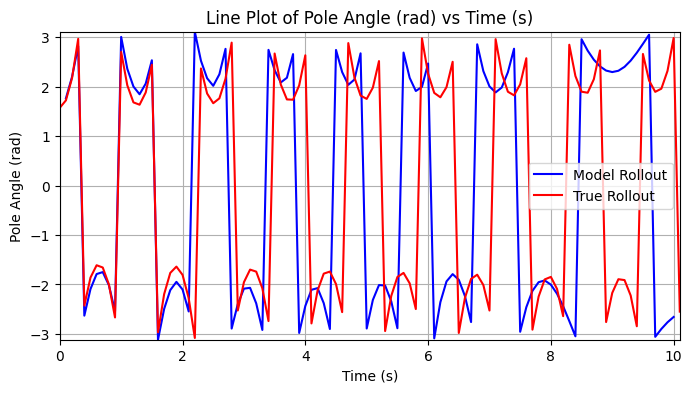

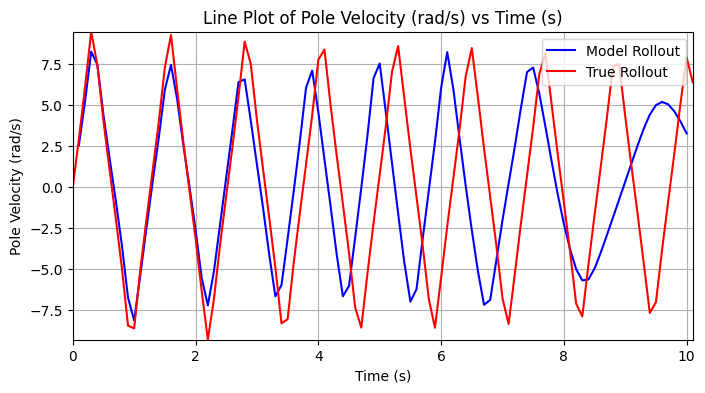

In [13]:
initial_state = [0.0, 0.0, jnp.pi/2, 0]
state_array = non_linear_rollout(initial_state, X_basis, alpha, sigma, 10)
true_state_array, _ = rollout(initial_state, 10)
axis_names_1 = ['Cart Location (m)','Cart Velocity (m/s)','Pole Angle (rad)','Pole Velocity (rad/s)','Time (s)']

#plot_model_graph(state_array, true_state_array, -1, 0, axis_names_1)
#plot_model_graph(state_array, true_state_array, -1, 1, axis_names_1)
plot_model_graph(state_array, true_state_array, -1, 2, axis_names_1)
plot_model_graph(state_array, true_state_array, -1, 3, axis_names_1)
#plot_model_graph(state_array, true_state_array, 2, 3, axis_names_1)
#plot_model_graph(state_array, true_state_array, 2, 1, axis_names_1)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=58725ef8-9a26-4e31-9e4c-5d3613b1a28f' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>